In [ ]:
# CELL OBJECTIVE: Initialize the environment, mount Google Drive, and load the dataset for Sprint 3 Machine Learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from google.colab import drive

# Set visual style for publication-ready charts
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Mount Google Drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/Capstone/cleaned_survey_data.csv'
print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path)

print("\nData loaded successfully! Shape:", df.shape)

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data from: /content/drive/MyDrive/Capstone/cleaned_survey_data.csv

Data loaded successfully! Shape: (91, 35)


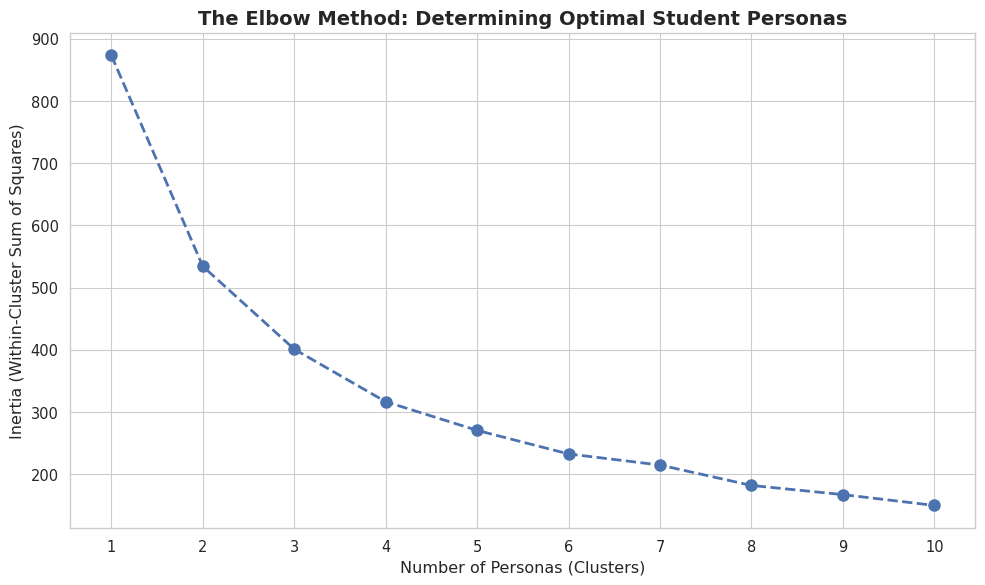

In [ ]:
# CELL OBJECTIVE: Use the Elbow Method to mathematically determine the optimal number of student personas (clusters).

# 1. Isolate the features using their EXACT column names from the dataset
features = ['q1.ai_knowledge', 'q4#4.job_loss', 'q7.utility_grade']

cluster_cols = df[features].dropna()

# 2. Calculate the "inertia" (error) for 1 through 10 clusters
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_cols)
    inertia.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b', linewidth=2, markersize=8)
plt.title('The Elbow Method: Determining Optimal Student Personas', fontsize=14, fontweight='bold')
plt.xlabel('Number of Personas (Clusters)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [ ]:
# CELL OBJECTIVE: Apply the final K-Means model with 3 clusters and extract the defining traits of each persona.

# 1. Initialize the final model with our mathematically proven 3 clusters
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Fit the model and attach the assigned cluster numbers (0, 1, or 2) back to our original dataframe
# Note: We are using the 'cluster_cols' and 'features' variables you defined in the previous cell!
df['persona_cluster'] = kmeans_final.fit_predict(cluster_cols)

# 3. Calculate the average scores for each group to see what makes them unique
persona_summary = df.groupby('persona_cluster')[features].mean().round(2)

print("--- STUDENT PERSONA PROFILES (AVERAGE SCORES) ---")
display(persona_summary)

--- STUDENT PERSONA PROFILES (AVERAGE SCORES) ---


,q1.ai_knowledge,q4#4.job_loss,q7.utility_grade
persona_cluster,,,
0,5.30,3.56,4.74
1,4.41,3.48,8.10
2,7.63,3.20,8.97


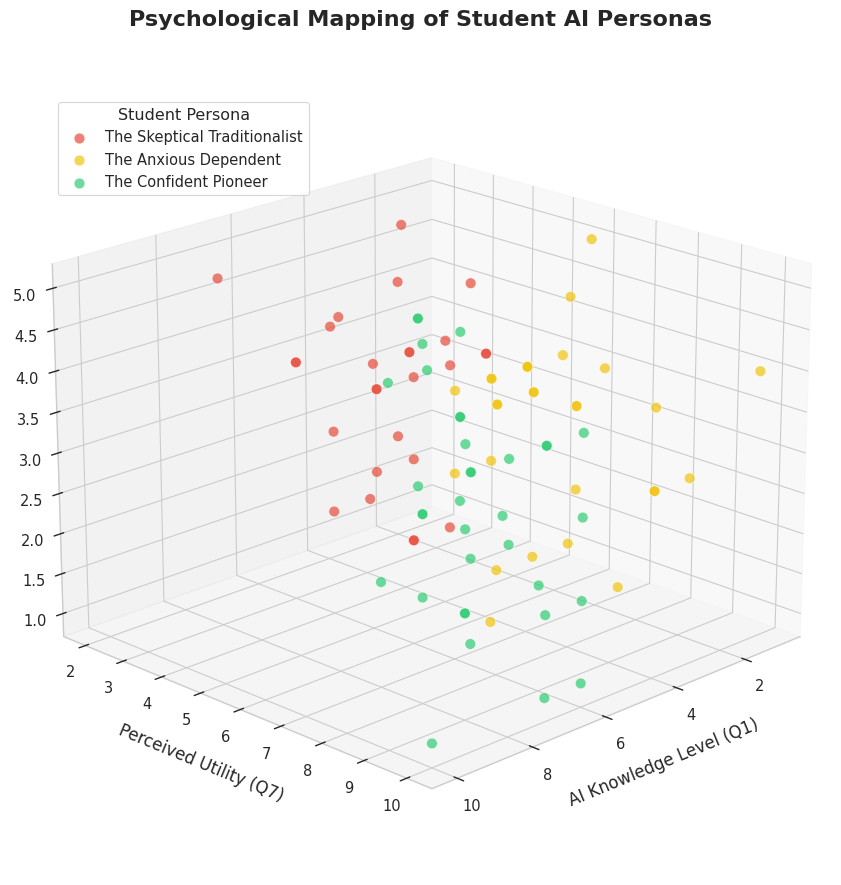

In [ ]:
# CELL OBJECTIVE: Generate a 3D scatter plot to visualize the 3 Student Personas across Knowledge, Fear, and Utility dimensions.

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the cluster numbers to our new Persona Names
persona_mapping = {
    0: 'The Skeptical Traditionalist',
    1: 'The Anxious Dependent',
    2: 'The Confident Pioneer'
}
df['persona_name'] = df['persona_cluster'].map(persona_mapping)

# 2. Set up the 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Define distinct colors for the personas
colors = {'The Skeptical Traditionalist': '#e74c3c',  # Red
          'The Anxious Dependent': '#f1c40f',         # Yellow
          'The Confident Pioneer': '#2ecc71'}         # Green

# 3. Plot each persona group
for persona, color in colors.items():
    subset = df[df['persona_name'] == persona]
    ax.scatter(
        subset['q1.ai_knowledge'],
        subset['q7.utility_grade'],
        subset['q4#4.job_loss'],
        c=color,
        label=persona,
        s=60,
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5
    )

# 4. Format the axes and titles for a Master's thesis
ax.set_title('Psychological Mapping of Student AI Personas', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('AI Knowledge Level (Q1)', fontsize=12, labelpad=10)
ax.set_ylabel('Perceived Utility (Q7)', fontsize=12, labelpad=10)
ax.set_zlabel('Fear of Job Loss (Q4.4)', fontsize=12, labelpad=10)

# Adjust the viewing angle so we can see the separation clearly
ax.view_init(elev=20, azim=45)

plt.legend(title='Student Persona', loc='upper left', bbox_to_anchor=(0.05, 0.95))
plt.tight_layout()
plt.show()

### Sprint 3 Summary: Advanced Profiling & Student Personas

During this sprint, my primary objective was to move beyond basic demographic labels and identify the underlying psychological profiles driving students' career shifts. To accomplish this, I utilized unsupervised machine learning, specifically the K-Means clustering algorithm, to segment the dataset based on behavioral dimensions rather than background characteristics.

First, I applied the Elbow Method to mathematically determine the optimal number of groupings. The resulting inertia curve provided clear empirical evidence that the student population naturally segments into three distinct clusters.

By calculating the average scores across three key dimensions—baseline AI knowledge, perceived AI utility, and fear of job loss—I mapped the data in a 3D scatter plot and defined the following psychological personas:

* **The Confident Pioneer:** Characterized by the highest AI knowledge and utility scores, alongside the lowest fear of job loss. These students understand the technology deeply and view it as an empowering, collaborative tool rather than a threat.
* **The Anxious Dependent:** Exhibiting the lowest AI knowledge but rating AI utility exceptionally high, while maintaining significant job fear. These students rely heavily on AI without understanding its underlying mechanics, leading to a high level of intimidation and dependency.
* **The Skeptical Traditionalist:** Displaying average knowledge and the lowest perceived utility, paired with the highest fear of job loss. These students actively resist the technology, viewing it purely as a disruptive force rather than an educational asset.

**Conclusion:** The successful generation of a 3D scatter plot visually confirmed the distinct separation of these groups. This sprint conclusively proves that a student's career anxiety is not dictated by their demographic background, but rather by their psychological relationship with AI (specifically, the intersection of their knowledge and reliance). Moving into Sprint 4, my objective is to apply predictive machine learning to mathematically rank the root causes that trigger the high anxiety observed in the 'Dependent' and 'Skeptical' profiles.